# Épaisseur corticale après JDAC et ses variantes (ds004332, pipeline rigide)

**Question.** Chaque condition corrige-t-elle le mouvement (l'épaisseur mesurée ne dépend plus du mouvement), le lisse-t-elle (elle abaisse l'épaisseur même sans mouvement), ou le sur-corrige-t-elle (elle inverse le lien) ?

**Cinq conditions** (toutes en rigide) : `brut`, `preproc`, `jdac` (complet), `jdac_antiartonly` (anti-artefact ×1), `jdac_nodenoise` (anti-artefact ×4, sans débruiteur).

**Unité.** Épaisseurs en **mm** ; mouvement = score Agitation (sans unité). Trois runs par sujet : run-01 immobile (still), run-02 (nodding), run-03 bougé (shaking).

**Sources** : brut `results/ds004332/phase1_RAW/ThickAvg_phase1_complete.csv` ; preproc/jdac `derivatives/ds004332/thickness_{preproc,jdac}_rigid_{lh,rh}.csv` ; variantes `derivatives/ds004332/thickness_jdac_{antiartonly,nodenoise}_rigid/…` ; Agitation `results/ds004332/agitation/ds004332_agitation_clinica.csv` ; âge/sexe `raw_datasets/ds004332/participants.tsv`.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.formula.api as smf
from IPython.display import display
import warnings; warnings.filterwarnings("ignore")

def show(df, question, analyse, fmt="{:.3f}"):
    # Tableau précédé de la question, suivi de l'analyse des résultats.
    print("Question :", question)
    display(df.style.format(fmt, na_rep="—").set_table_styles([
        {"selector": "th", "props": "background-color:#d9e1f2;padding:5px 12px;font-size:12px;"},
        {"selector": "td", "props": "padding:5px 12px;font-size:12px;text-align:right;"},
        {"selector": "tbody tr:nth-child(odd)", "props": "background-color:#f6f6f6;"}]))
    print("Analyse :", analyse)

HOME  = Path.home()
REPO  = HOME / "Documents/jdac-motion-correction"
DERIV = HOME / "Documents/derivatives/ds004332"
CONDITIONS = ["brut", "preproc", "jdac", "jdac_antiartonly", "jdac_nodenoise"]
SHORT = {"brut": "brut", "preproc": "prep", "jdac": "jdac",
         "jdac_antiartonly": "aa×1", "jdac_nodenoise": "nod×4"}
CONSIGNE = {"run-01": "still", "run-02": "nodding", "run-03": "shaking"}
WIDE = {"preproc": "thickness_preproc_rigid_{h}.csv",
        "jdac": "thickness_jdac_rigid_{h}.csv",
        "jdac_antiartonly": "thickness_jdac_antiartonly_rigid/thickness_jdac_antiartonly_rigid_{h}.csv",
        "jdac_nodenoise": "thickness_jdac_nodenoise_rigid/thickness_jdac_nodenoise_rigid_{h}.csv"}

def load_brut():
    d = pd.read_csv(REPO / "results/ds004332/phase1_RAW/ThickAvg_phase1_complete.csv")
    d = d[d["ThickAvg"] > 0].copy()
    d["run"] = d["subject"].str.split("_").str[1]
    d["subject"] = d["subject"].str.split("_").str[0]
    return d.rename(columns={"ThickAvg": "thickness"}).assign(condition="brut")[
        ["subject", "run", "thickness", "condition"]]

def load_wide(cond):
    frames = []
    for hemi in ["lh", "rh"]:
        w = pd.read_csv(DERIV / WIDE[cond].format(h=hemi), sep="\t")
        w = w.rename(columns={w.columns[0]: "id"})
        cols = [c for c in w.columns if c.endswith("_thickness") and "MeanThickness" not in c]
        long = w.melt(id_vars="id", value_vars=cols, value_name="thickness")
        long["subject"] = long["id"].str.split("_").str[0]
        long["run"] = long["id"].str.split("_").str[1]
        frames.append(long)
    return pd.concat(frames, ignore_index=True).assign(condition=cond)[
        ["subject", "run", "thickness", "condition"]]

# Épaisseur corticale moyenne (mm) par acquisition (moyenne des régions des 2 hémisphères)
thick = pd.concat([load_brut()] + [load_wide(c) for c in CONDITIONS if c != "brut"], ignore_index=True)
thick = thick[thick["thickness"] > 0]
g = thick.groupby(["subject", "run", "condition"], observed=True)["thickness"].mean().reset_index()

agit = pd.read_csv(REPO / "results/ds004332/agitation/ds004332_agitation_clinica.csv") \
         .rename(columns={"condition": "run", "sub": "subject", "motion": "agitation"})
demog = pd.read_csv(HOME / "Documents/raw_datasets/ds004332/participants.tsv", sep="\t") \
          .rename(columns={"participant_id": "subject"})
demog["sex_bin"] = (demog["sex"] == "F").astype(int)
g = g.merge(agit[["subject", "run", "agitation"]], on=["subject", "run"], how="left")
g = g.merge(demog[["subject", "age", "sex_bin"]], on="subject", how="left")
g["consigne"] = g["run"].map(CONSIGNE)
g["condition"] = pd.Categorical(g["condition"], categories=CONDITIONS, ordered=True)

print("Acquisitions par condition (une par sujet × run) :")
print(g.groupby("condition", observed=True).size().to_string())
print("\nÉpaisseur = moyenne des régions FreeSurfer, en mm. Une ligne = un sujet × run × condition.")

Acquisitions par condition (une par sujet × run) :
condition
brut                65
preproc             64
jdac                64
jdac_antiartonly    66
jdac_nodenoise      65

Épaisseur = moyenne des régions FreeSurfer, en mm. Une ligne = un sujet × run × condition.


## A. Effet sur un scan immobile (offset / lissage)

Sur un scan immobile (run-01), il n'y a pas de mouvement à corriger : toute différence d'épaisseur entre conditions vient du traitement lui-même.

In [2]:
imm = g[g["consigne"] == "still"]
tA = imm.groupby("condition", observed=True)["thickness"].agg(["mean", "std", "count"]).reindex(CONDITIONS)
tA.columns = ["épaisseur immobile (mm)", "écart-type (mm)", "n sujets"]
ref = tA.loc["brut", "épaisseur immobile (mm)"]
tA["écart au brut (mm)"] = tA["épaisseur immobile (mm)"] - ref
tA["écart au brut (%)"] = 100 * tA["écart au brut (mm)"] / ref

o = tA["écart au brut (mm)"].drop("brut")
analyse = (f"Les quatre traitements amincissent tous un cerveau immobile (écart au brut de {o.max():+.3f} à "
           f"{o.min():+.3f} mm), le plus fort étant {o.idxmin()} ({o.min():+.3f} mm). L'écart se creuse à mesure "
           f"qu'on applique l'anti-artefact (preproc, puis jdac, puis les variantes). Sur un immobile il n'y a rien "
           f"à corriger : cet écart mesure un lissage/offset, pas une correction.")
show(tA, "Sur les scans immobiles, chaque condition change-t-elle l'épaisseur par rapport au brut ?", analyse,
     {"épaisseur immobile (mm)": "{:.3f}", "écart-type (mm)": "{:.3f}", "n sujets": "{:.0f}",
      "écart au brut (mm)": "{:+.3f}", "écart au brut (%)": "{:+.1f}"})

Question : Sur les scans immobiles, chaque condition change-t-elle l'épaisseur par rapport au brut ?


,épaisseur immobile (mm),écart-type (mm),n sujets,écart au brut (mm),écart au brut (%)
condition,,,,,
brut,2.595,0.061,22,+0.000,+0.0
preproc,2.518,0.068,21,-0.077,-3.0
jdac,2.435,0.101,22,-0.160,-6.2
jdac_antiartonly,2.418,0.117,22,-0.177,-6.8
jdac_nodenoise,2.378,0.099,21,-0.216,-8.3


Analyse : Les quatre traitements amincissent tous un cerveau immobile (écart au brut de -0.077 à -0.216 mm), le plus fort étant jdac_nodenoise (-0.216 mm). L'écart se creuse à mesure qu'on applique l'anti-artefact (preproc, puis jdac, puis les variantes). Sur un immobile il n'y a rien à corriger : cet écart mesure un lissage/offset, pas une correction.


## B. Immobile vs bougé, sujet par sujet

Vue sur les données brutes. Pour chaque sujet, son scan immobile (run-01) et son scan bougé (run-03) : si une condition corrige le mouvement, les deux valeurs se rapprochent ; si elle sur-corrige, le bougé passe au-dessus de l'immobile. Un panneau par sujet (`sub-19` en évidence), épaisseur en mm.

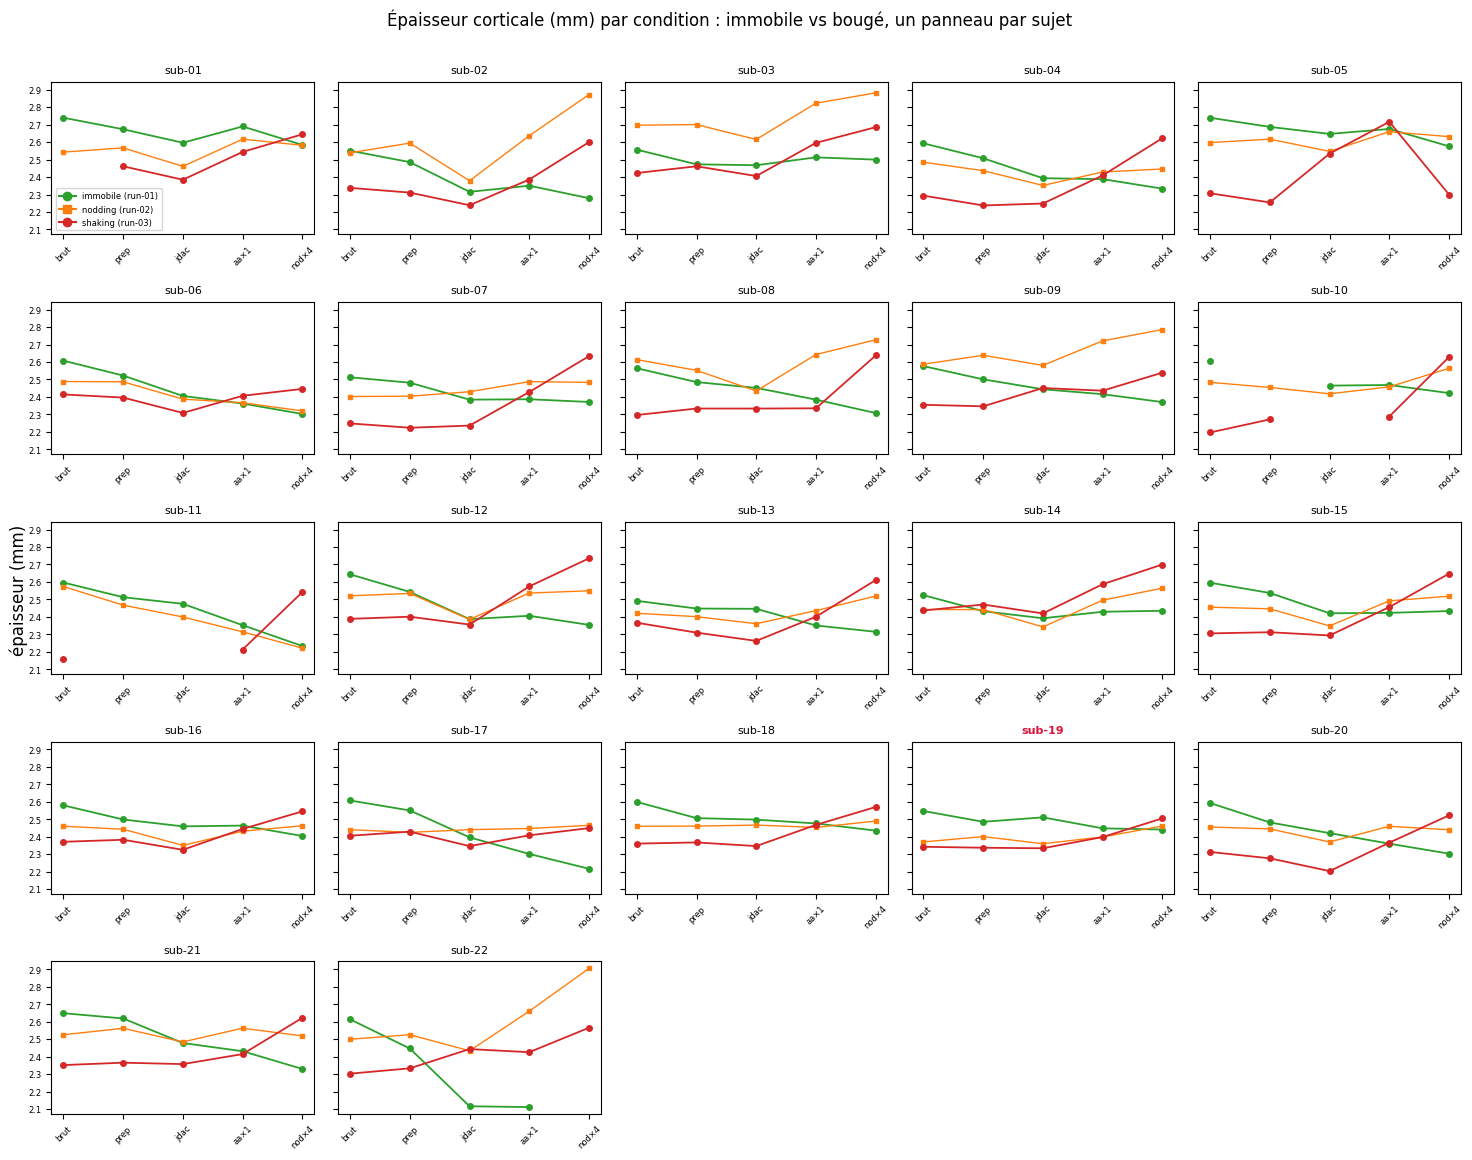

Analyse : en brut le point bougé (rouge) est sous l'immobile (vert) chez la plupart des sujets (bougé plus épais chez seulement 0), le mouvement amincit. Sous nodenoise le bougé passe au-dessus de l'immobile chez 20 sujets et 14 sous antiartonly : sur-correction visible. jdac et preproc restent proches du comportement du brut.


In [3]:
pv = g.pivot_table(index=["subject", "condition"], columns="consigne", values="thickness", observed=True)
subjects = sorted(g["subject"].unique())
ncol = 5; nrow = int(np.ceil(len(subjects) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(3.0 * ncol, 2.3 * nrow), sharey=True)
xpos = np.arange(len(CONDITIONS))
for ax, subj in zip(axes.ravel(), subjects):
    nod   = [pv.loc[(subj, c), "nodding"] if (subj, c) in pv.index else np.nan for c in CONDITIONS]
    still = [pv.loc[(subj, c), "still"] if (subj, c) in pv.index else np.nan for c in CONDITIONS]
    shak  = [pv.loc[(subj, c), "shaking"] if (subj, c) in pv.index else np.nan for c in CONDITIONS]
    ax.plot(xpos, still, "-o", color="tab:green",  ms=4, lw=1.3)
    ax.plot(xpos, nod,   "-s", color="tab:orange", ms=3, lw=1.0)
    ax.plot(xpos, shak,  "-o", color="tab:red",    ms=4, lw=1.3)
    hot = (subj == "sub-19")
    ax.set_title(subj, fontsize=8, color=("crimson" if hot else "black"), fontweight=("bold" if hot else "normal"))
    ax.set_xticks(xpos); ax.set_xticklabels([SHORT[c] for c in CONDITIONS], fontsize=6, rotation=45)
    ax.tick_params(labelsize=6)
for ax in axes.ravel()[len(subjects):]:
    ax.axis("off")
axes.ravel()[0].plot([], [], "-o", color="tab:green",  label="immobile (run-01)")
axes.ravel()[0].plot([], [], "-s", color="tab:orange", label="nodding (run-02)")
axes.ravel()[0].plot([], [], "-o", color="tab:red",    label="shaking (run-03)")
axes.ravel()[0].legend(fontsize=6, loc="best")
fig.suptitle("Épaisseur corticale (mm) par condition : immobile vs bougé, un panneau par sujet", y=1.005)
fig.supylabel("épaisseur (mm)")
plt.tight_layout(); plt.show()

over = {}
for c in CONDITIONS:
    sub = pv.xs(c, level="condition")[["still", "shaking"]].dropna()
    over[c] = int((sub["shaking"] > sub["still"]).sum())
print(f"Analyse : en brut le point bougé (rouge) est sous l'immobile (vert) chez la plupart des sujets "
      f"(bougé plus épais chez seulement {over['brut']}), le mouvement amincit. Sous nodenoise le bougé passe "
      f"au-dessus de l'immobile chez {over['jdac_nodenoise']} sujets et {over['jdac_antiartonly']} sous antiartonly : "
      f"sur-correction visible. jdac et preproc restent proches du comportement du brut.")

Le décompte chiffre la figure : pour chaque sujet, l'écart immobile − bougé (mm) est comparé entre le brut et la condition.

In [4]:
ec = pv.reset_index().dropna(subset=["still", "shaking"])
ec["ecart"] = ec["still"] - ec["shaking"]          # > 0 : le mouvement amincit
w = ec.pivot(index="subject", columns="condition", values="ecart")

rows = []
for c in CONDITIONS:
    if c == "brut":
        continue
    p = w[["brut", c]].dropna()
    p = p[p["brut"] > 0]
    rows.append({"condition": c, "n sujets": len(p),
                 "améliorés": int(((p[c] >= 0) & (p[c] < p["brut"])).sum()),
                 "sur-corrigés": int((p[c] < 0).sum()),
                 "inchangés/pires": int((p[c] >= p["brut"]).sum()),
                 "écart médian brut (mm)": p["brut"].median(),
                 "écart médian condition (mm)": p[c].median()})
tB = pd.DataFrame(rows).set_index("condition")

analyse = (f"preproc et jdac réduisent l'écart chez la majorité ({tB.loc['preproc','améliorés']:.0f} et "
           f"{tB.loc['jdac','améliorés']:.0f} sujets améliorés sur ~{tB.loc['jdac','n sujets']:.0f}), avec peu de sur-corrigés. "
           f"Les variantes sans débruiteur sur-corrigent la majorité : {tB.loc['jdac_antiartonly','sur-corrigés']:.0f} sujets "
           f"pour antiartonly, {tB.loc['jdac_nodenoise','sur-corrigés']:.0f} pour nodenoise (le bougé devient plus épais que "
           f"l'immobile). Réserve : cet écart mélange récupération et offset — la section E tranche par région.")
show(tB, "Chez combien de sujets l'écart immobile − bougé se réduit vraiment (sans s'inverser) ?", analyse,
     {"n sujets": "{:.0f}", "améliorés": "{:.0f}", "sur-corrigés": "{:.0f}", "inchangés/pires": "{:.0f}",
      "écart médian brut (mm)": "{:.3f}", "écart médian condition (mm)": "{:.3f}"})

Question : Chez combien de sujets l'écart immobile − bougé se réduit vraiment (sans s'inverser) ?


,n sujets,améliorés,sur-corrigés,inchangés/pires,écart médian brut (mm),écart médian condition (mm)
condition,,,,,,
preproc,19,16,1,2,0.239,0.148
jdac,19,15,3,1,0.239,0.118
jdac_antiartonly,21,7,14,0,0.255,-0.033
jdac_nodenoise,20,1,19,0,0.247,-0.226


Analyse : preproc et jdac réduisent l'écart chez la majorité (16 et 15 sujets améliorés sur ~19), avec peu de sur-corrigés. Les variantes sans débruiteur sur-corrigent la majorité : 14 sujets pour antiartonly, 19 pour nodenoise (le bougé devient plus épais que l'immobile). Réserve : cet écart mélange récupération et offset — la section E tranche par région.


## C. Le mouvement prédit-il encore l'épaisseur ? (modèles M0 vs M1)

Pour chaque condition, deux modèles sur l'épaisseur moyenne par acquisition, avec un effet aléatoire par sujet : **M0** = âge + sexe ; **M1** = M0 + score Agitation. La **p-value** est la probabilité d'un gain d'ajustement aussi grand si le mouvement n'avait aucun effet (< 0.05 = le mouvement apporte de l'information ; grande = il n'en apporte plus). Le **coefficient** d'Agitation (mm par point) donne le sens et l'ampleur.

In [5]:
def fit(formula, d):
    return smf.mixedlm(formula, d, groups=d["subject"]).fit(reml=False, method="powell", disp=False)

rows = []
for c in CONDITIONS:
    d = g[g["condition"] == c].dropna(subset=["age", "sex_bin", "agitation", "thickness"])
    m0 = fit("thickness ~ age + sex_bin", d)
    m1 = fit("thickness ~ age + sex_bin + agitation", d)
    lr = 2 * (m1.llf - m0.llf)
    coef = m1.params["agitation"]
    rows.append({"condition": c, "n acquisitions": d.groupby(["subject", "run"]).ngroups,
                 "coef Agitation (mm/point)": coef, "p (M1 vs M0)": stats.chi2.sf(lr, 1),
                 "sens": "amincit" if coef < 0 else "épaissit"})
tC = pd.DataFrame(rows).set_index("condition")

ns = [c for c in CONDITIONS if tC.loc[c, "p (M1 vs M0)"] >= 0.05]
analyse = (f"En brut le mouvement prédit fortement l'épaisseur (coef {tC.loc['brut','coef Agitation (mm/point)']:+.4f} mm/point, "
           f"p={tC.loc['brut','p (M1 vs M0)']:.1g}) : il l'amincit. Le mouvement ne prédit plus l'épaisseur (p≥0.05) pour : "
           f"{', '.join(ns) if ns else 'aucune condition'} — jdac réalise le meilleur découplage (p={tC.loc['jdac','p (M1 vs M0)']:.2g}). "
           f"antiartonly et nodenoise ont un coefficient positif ({tC.loc['jdac_nodenoise','coef Agitation (mm/point)']:+.4f}, "
           f"p={tC.loc['jdac_nodenoise','p (M1 vs M0)']:.1g} pour nodenoise) : le mouvement épaissit l'épaisseur mesurée = sur-correction.")
show(tC, "Après la condition, ajouter le score de mouvement améliore-t-il encore le modèle ?", analyse,
     {"n acquisitions": "{:.0f}", "coef Agitation (mm/point)": "{:+.4f}", "p (M1 vs M0)": "{:.2g}", "sens": "{}"})

Question : Après la condition, ajouter le score de mouvement améliore-t-il encore le modèle ?


,n acquisitions,coef Agitation (mm/point),p (M1 vs M0),sens
condition,,,,
brut,65,-0.0662,6.6e-05,amincit
preproc,64,-0.0308,0.028,amincit
jdac,64,-0.0203,0.11,amincit
jdac_antiartonly,66,+0.0253,0.081,épaissit
jdac_nodenoise,65,+0.0923,7.1e-07,épaissit


Analyse : En brut le mouvement prédit fortement l'épaisseur (coef -0.0662 mm/point, p=7e-05) : il l'amincit. Le mouvement ne prédit plus l'épaisseur (p≥0.05) pour : jdac, jdac_antiartonly — jdac réalise le meilleur découplage (p=0.11). antiartonly et nodenoise ont un coefficient positif (+0.0923, p=7e-07 pour nodenoise) : le mouvement épaissit l'épaisseur mesurée = sur-correction.


## D. Contours vs scan propre (protocole d'évaluation de JDAC)

L'épaisseur seule ne distingue pas correction et lissage. On reprend donc l'évaluation de l'article JDAC : comparer, en pleine référence, chaque scan bougé au scan **propre** du même sujet, sur l'image **et sur les cartes de gradient** (les contours). Images sur la même grille rigide, aucun recalage. SSIM entre 0 et 1 (1 = identique au propre), moyennée sur les sujets. Métriques calculées par `compute_image_metrics.py`.

In [6]:
im = pd.read_csv(REPO / "results/ds004332/phase4_compare_3bras/image_metrics.csv")
IMGCONDS = ["preproc", "jdac", "jdac_antiartonly", "jdac_nodenoise"]
lab = {"run-02": "nodding (mvt modéré)", "run-03": "shaking (fort mvt)"}
agg = im.groupby(["condition", "run"])[["clean_ssim_img", "clean_ssim_grad", "intra_ssim_grad"]].mean()
s = agg.xs("run-03", level="run")   # au fort mouvement, pour l'analyse

A_img = (f"Contre le scan propre, la ressemblance d'image monte légèrement après correction au fort mouvement "
         f"(preproc {s.loc['preproc','clean_ssim_img']:.3f}, jdac {s.loc['jdac','clean_ssim_img']:.3f}, "
         f"nodenoise {s.loc['jdac_nodenoise','clean_ssim_img']:.3f}), mais l'image seule ne sépare pas correction et lissage.")
A_grad = (f"Sur les contours, contre le propre non traité, aucune condition ne dépasse nettement preproc au fort mouvement "
          f"(preproc {s.loc['preproc','clean_ssim_grad']:.3f}, jdac {s.loc['jdac','clean_ssim_grad']:.3f}, "
          f"nodenoise {s.loc['jdac_nodenoise','clean_ssim_grad']:.3f}). Ce test mélange correction et changement d'intensité, "
          f"d'où le tableau intra ci-dessous.")
A_intra = (f"Sans le biais d'intensité (contre son propre immobile), jdac gagne nettement en contours au fort mouvement "
           f"({s.loc['jdac','intra_ssim_grad']:.3f} vs preproc {s.loc['preproc','intra_ssim_grad']:.3f}) = mouvement réduit. "
           f"nodenoise ne gagne pas ({s.loc['jdac_nodenoise','intra_ssim_grad']:.3f}, ≤ preproc) : sa netteté ne correspond "
           f"pas à l'anatomie propre.")

show(agg["clean_ssim_img"].unstack("run").reindex(IMGCONDS).rename(columns=lab),
     "SSIM image vs scan propre (moyenne sujets, 0 = différent, 1 = identique)", A_img)
show(agg["clean_ssim_grad"].unstack("run").reindex(IMGCONDS).rename(columns=lab),
     "SSIM des contours (gradient) vs scan propre", A_grad)
show(agg["intra_ssim_grad"].unstack("run").reindex(IMGCONDS).rename(columns=lab),
     "SSIM des contours vs le scan immobile de la MÊME condition (sans le biais d'intensité)", A_intra)

Question : SSIM image vs scan propre (moyenne sujets, 0 = différent, 1 = identique)


run,nodding (mvt modéré),shaking (fort mvt)
condition,,
preproc,0.729,0.540
jdac,0.745,0.561
jdac_antiartonly,0.743,0.552
jdac_nodenoise,0.734,0.555


Analyse : Contre le scan propre, la ressemblance d'image monte légèrement après correction au fort mouvement (preproc 0.540, jdac 0.561, nodenoise 0.555), mais l'image seule ne sépare pas correction et lissage.
Question : SSIM des contours (gradient) vs scan propre


run,nodding (mvt modéré),shaking (fort mvt)
condition,,
preproc,0.632,0.489
jdac,0.620,0.487
jdac_antiartonly,0.643,0.493
jdac_nodenoise,0.617,0.479


Analyse : Sur les contours, contre le propre non traité, aucune condition ne dépasse nettement preproc au fort mouvement (preproc 0.489, jdac 0.487, nodenoise 0.479). Ce test mélange correction et changement d'intensité, d'où le tableau intra ci-dessous.
Question : SSIM des contours vs le scan immobile de la MÊME condition (sans le biais d'intensité)


run,nodding (mvt modéré),shaking (fort mvt)
condition,,
preproc,0.632,0.489
jdac,0.696,0.529
jdac_antiartonly,0.645,0.489
jdac_nodenoise,0.632,0.471


Analyse : Sans le biais d'intensité (contre son propre immobile), jdac gagne nettement en contours au fort mouvement (0.529 vs preproc 0.489) = mouvement réduit. nodenoise ne gagne pas (0.471, ≤ preproc) : sa netteté ne correspond pas à l'anatomie propre.


## E. Les mesures suivent-elles ? Récupération vers la vraie épaisseur (par région, mm)

Question de fond pour un article : pour un scan bougé, l'épaisseur **par région** se rapproche-t-elle de la vraie valeur (le scan immobile du même sujet) après correction ? On évite la moyenne globale (qui peut coïncider par hasard) et on mesure la distance région par région. Trois distances : **mouvement restant** (écart au scan immobile de la même condition, net d'offset), **erreur à la vérité** (écart au scan immobile brut), **offset** (distorsion appliquée à un scan propre). Métriques calculées par `compute_recovery.py`.

In [7]:
rec = pd.read_csv(REPO / "results/ds004332/phase4_compare_3bras/recovery_metrics.csv")
RCONDS = ["brut", "preproc", "jdac", "jdac_antiartonly", "jdac_nodenoise"]
for run, cons in [("run-03", "shaking (fort mouvement)"), ("run-02", "nodding (mouvement modéré)")]:
    t = (rec[rec["run"] == run].groupby("condition")[["mae_within", "mae_truth", "offset"]].mean().reindex(RCONDS))
    bt, bw = t.loc["brut", "mae_truth"], t.loc["brut", "mae_within"]
    analyse = (f"Aucune condition ne descend sous l'erreur du brut à la vérité ({bt:.3f} mm) : jdac {t.loc['jdac','mae_truth']:.3f}, "
               f"nodenoise {t.loc['jdac_nodenoise','mae_truth']:.3f} s'en éloignent (à cause de l'offset). Net d'offset "
               f"(mouvement restant), nodenoise empire le motif régional ({t.loc['jdac_nodenoise','mae_within']:.3f} > brut {bw:.3f}) ; "
               f"seul preproc le réduit un peu ({t.loc['preproc','mae_within']:.3f}). L'épaisseur régionale du scan bougé ne se "
               f"rapproche donc pas de la vraie valeur : les mesures ne suivent pas.")
    t.columns = ["mouvement restant (mm)", "erreur à la vérité (mm)", "offset sur le propre (mm)"]
    show(t, f"Scan {cons} : l'épaisseur régionale se rapproche-t-elle de la vraie valeur (immobile brut) ?", analyse, "{:.3f}")

Question : Scan shaking (fort mouvement) : l'épaisseur régionale se rapproche-t-elle de la vraie valeur (immobile brut) ?


,mouvement restant (mm),erreur à la vérité (mm),offset sur le propre (mm)
condition,,,
brut,0.315,0.315,0.000
preproc,0.271,0.311,0.087
jdac,0.317,0.373,0.232
jdac_antiartonly,0.341,0.314,0.193
jdac_nodenoise,0.415,0.336,0.255


Analyse : Aucune condition ne descend sous l'erreur du brut à la vérité (0.315 mm) : jdac 0.373, nodenoise 0.336 s'en éloignent (à cause de l'offset). Net d'offset (mouvement restant), nodenoise empire le motif régional (0.415 > brut 0.315) ; seul preproc le réduit un peu (0.271). L'épaisseur régionale du scan bougé ne se rapproche donc pas de la vraie valeur : les mesures ne suivent pas.
Question : Scan nodding (mouvement modéré) : l'épaisseur régionale se rapproche-t-elle de la vraie valeur (immobile brut) ?


,mouvement restant (mm),erreur à la vérité (mm),offset sur le propre (mm)
condition,,,
brut,0.256,0.256,0.000
preproc,0.252,0.264,0.088
jdac,0.307,0.350,0.230
jdac_antiartonly,0.328,0.298,0.193
jdac_nodenoise,0.323,0.320,0.255


Analyse : Aucune condition ne descend sous l'erreur du brut à la vérité (0.256 mm) : jdac 0.350, nodenoise 0.320 s'en éloignent (à cause de l'offset). Net d'offset (mouvement restant), nodenoise empire le motif régional (0.323 > brut 0.256) ; seul preproc le réduit un peu (0.252). L'épaisseur régionale du scan bougé ne se rapproche donc pas de la vraie valeur : les mesures ne suivent pas.


## Synthèse

Bilan des cinq conditions sur les questions A à E. Les deux variantes sans débruiteur (antiartonly ×1, nodenoise ×4) **sur-corrigent** : elles inversent le lien mouvement–épaisseur (C, coefficient positif) et, une fois l'offset retiré, elles éloignent l'épaisseur régionale du scan bougé de la vraie valeur au lieu de l'en rapprocher (E), sans gagner en fidélité des contours (D). `jdac` complet est la seule à découpler le mouvement (C) et à rapprocher les contours du propre (D), mais au prix d'un lissage qui amincit les scans immobiles (A). Une partie du bénéfice vient déjà du `preprocessing` seul (B, E). Conclusion : aucune condition ne ramène l'épaisseur d'un scan bougé à sa vraie valeur, et la meilleure image des variantes ne se traduit pas en mesure corticale plus fidèle.